#  Statistical Estimation and Inference

This notebook contains the statistical core of Team C's experimentation
analysis.

The analysis is performed only on experiments that passed the data
integrity checks.

Invalid experiments:

- EXP-005
- EXP-010

Analysable experiments:

- EXP-001
- EXP-002
- EXP-003
- EXP-004
- EXP-006
- EXP-007
- EXP-008
- EXP-009

The main statistical tasks are:

1. Estimate conversion rates and treatment effects.
2. Perform two-proportion z-tests.
3. Calculate confidence intervals.
4. Calculate power to detect a 2% relative lift.
5. Analyse skewed revenue using bootstrap confidence intervals.
6. Perform Bayesian analysis.
7. Examine sequential testing.
8. Apply multiple-comparison correction.

The approach follows the derivation-first principle used in Project 1:
the statistical machinery is explained mathematically before being
implemented in code.

In [31]:
import pandas as pd
import numpy as np
from pathlib import Path
from math import sqrt, erf

In [32]:
DATA_DIR = Path.home() / "Downloads"

experiments = pd.read_csv(DATA_DIR / "experiments.csv.csv")
assignments = pd.read_csv(DATA_DIR / "assignments.csv.csv")
events = pd.read_csv(DATA_DIR / "events.csv.csv")
users = pd.read_csv(DATA_DIR / "users.csv.csv")

print("experiments:", experiments.shape)
print("assignments:", assignments.shape)
print("events:", events.shape)
print("users:", users.shape)

experiments: (10, 9)
assignments: (93050, 5)
events: (619048, 7)
users: (46000, 8)


## 2. Select the Analysable Experiments

The integrity analysis found that EXP-005 and EXP-010 failed the required
assignment checks.

Therefore, they must not be included in the statistical analysis.

This is important because statistical analysis should only be performed
after the underlying experiment data has been shown to be trustworthy.

In [33]:
analysable_experiments = [
    "EXP-001",
    "EXP-002",
    "EXP-003",
    "EXP-004",
    "EXP-006",
    "EXP-007",
    "EXP-008",
    "EXP-009"
]

a = assignments[
    assignments["experiment_id"].isin(analysable_experiments)
].copy()

e = events[
    events["experiment_id"].isin(analysable_experiments)
].copy()

print("Analysable assignments:", a.shape)
print("Analysable events:", e.shape)

Analysable assignments: (73618, 5)
Analysable events: (475582, 7)


## 3. Calculate User-Level Conversion

The event data contains daily observations for users.

The primary metric is conversion.

A user is considered converted if they have at least one event with
converted = 1.

Therefore, for each experiment and user, we take the maximum conversion
value:

- 0 = user never converted
- 1 = user converted at least once

This prevents a user with multiple event records from being counted as
multiple conversions.

In [34]:
user_conversion = (
    e.groupby(["experiment_id", "user_id"])["converted"]
    .max()
    .reset_index()
)

user_conversion["converted"] = (
    user_conversion["converted"].astype(int)
)

print(user_conversion.head())

  experiment_id   user_id  converted
0       EXP-001  UU700001          1
1       EXP-001  UU700004          0
2       EXP-001  UU700012          1
3       EXP-001  UU700013          0
4       EXP-001  UU700017          1


In [35]:
analysis_data = a.merge(
    user_conversion,
    on=["experiment_id", "user_id"],
    how="left"
)

analysis_data["converted"] = (
    analysis_data["converted"]
    .fillna(0)
    .astype(int)
)

print(analysis_data.head())

  assignment_id experiment_id   user_id    variant assigned_at  converted
0    AS-0016202       EXP-002  UU736547    control  2025-11-08          1
1    AS-0036736       EXP-004  UU730730  treatment  2026-04-29          1
2    AS-0064300       EXP-007  UU729627  treatment  2026-04-21          1
3    AS-0054684       EXP-006  UU712184  treatment  2026-04-01          1
4    AS-0036283       EXP-004  UU708956  treatment  02/05/2026          0


## 4. Conversion Rates by Variant

For each experiment we calculate:

conversion rate = number of conversions / number of users

The treatment effect is then:

effect = treatment conversion rate - control conversion rate

The effect is reported both as an absolute difference and as a relative
lift.


In [36]:
conversion_summary = (
    analysis_data
    .groupby(["experiment_id", "variant"])
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

conversion_summary["conversion_rate"] = (
    conversion_summary["conversions"]
    / conversion_summary["users"]
)

print(conversion_summary)

   experiment_id    variant  users  conversions  conversion_rate
0        EXP-001    control   4504         2165         0.480684
1        EXP-001  treatment   4509         2208         0.489687
2        EXP-002    control   4756         2343         0.492641
3        EXP-002  treatment   4757         2461         0.517343
4        EXP-003    control   5507         3223         0.585255
5        EXP-003  treatment   5511         3278         0.594810
6        EXP-004    control   4008         1461         0.364521
7        EXP-004  treatment   4011         1611         0.401645
8        EXP-006    control   5265         3108         0.590313
9        EXP-006  treatment   5258         3171         0.603081
10       EXP-007    control   4408         2183         0.495236
11       EXP-007  treatment   4406         2228         0.505674
12       EXP-008    control   3806         1377         0.361797
13       EXP-008  treatment   3803         1390         0.365501
14       EXP-009    contr

In [37]:
effect_summary = (
    conversion_summary
    .pivot(
        index="experiment_id",
        columns="variant",
        values="conversion_rate"
    )
    .reset_index()
)

effect_summary["absolute_effect"] = (
    effect_summary["treatment"]
    - effect_summary["control"]
)

effect_summary["relative_lift"] = (
    effect_summary["absolute_effect"]
    / effect_summary["control"]
)

print(effect_summary)


variant experiment_id   control  treatment  absolute_effect  relative_lift
0             EXP-001  0.480684   0.489687         0.009003       0.018731
1             EXP-002  0.492641   0.517343         0.024702       0.050142
2             EXP-003  0.585255   0.594810         0.009555       0.016327
3             EXP-004  0.364521   0.401645         0.037125       0.101845
4             EXP-006  0.590313   0.603081         0.012768       0.021629
5             EXP-007  0.495236   0.505674         0.010438       0.021077
6             EXP-008  0.361797   0.365501         0.003704       0.010237
7             EXP-009  0.497696   0.497583        -0.000112      -0.000226


## 5. Two-Proportion Z-Test — Derivation

We want to compare the conversion rate of the treatment group with the
conversion rate of the control group.

### Step 1: Calculate the two conversion rates

For the control group:

p_c = x_c / n_c

For the treatment group:

p_t = x_t / n_t

The observed difference is:

d = p_t - p_c

### Step 2: State the null hypothesis

We assume that the treatment has no effect:

H₀: p_t = p_c

This means that both groups have the same true conversion rate.

### Step 3: Find the standard error

For a proportion, the variance is:

Var(p) = p(1-p) / n

The two groups are independent, so their variances add:

Var(p_t - p_c)
= p(1-p)/n_t + p(1-p)/n_c

Under the null hypothesis, both groups have the same conversion rate.
We estimate this common rate using the pooled proportion:

p_pool = (x_t + x_c) / (n_t + n_c)

Therefore:

SE = sqrt[
    p_pool(1-p_pool)
    (1/n_t + 1/n_c)
]

### Step 4: Calculate the z-statistic

We divide the observed difference by its standard error:

z = (p_t - p_c) / SE

If the null hypothesis is true, this z-value follows approximately a
standard normal distribution.

### Step 5: Calculate the p-value

Because we want to detect either an improvement or a decrease, we use a
two-sided test:

p-value = 2 × P(Z >= |z|)

If the p-value is less than 0.05, we reject the null hypothesis.

If the p-value is greater than or equal to 0.05, we do not reject the
null hypothesis.

A non-significant result does not prove that there is no treatment
effect. Confidence intervals and statistical power must also be examined.

### Assumptions

The test assumes that:

1. Users are independently assigned to treatment or control.
2. Each user has a binary outcome: converted or not converted.
3. The treatment and control groups are independent.
4. The sample sizes are large enough for the normal approximation.
5. The experiment has passed the integrity checks.

In [38]:
def two_proportion_z_test(
    conversions_control,
    users_control,
    conversions_treatment,
    users_treatment
):
    p_control = conversions_control / users_control
    p_treatment = conversions_treatment / users_treatment

    difference = p_treatment - p_control

    pooled_rate = (
        conversions_control + conversions_treatment
    ) / (
        users_control + users_treatment
    )

    standard_error = sqrt(
        pooled_rate * (1 - pooled_rate)
        * (
            1 / users_control
            + 1 / users_treatment
        )
    )

    z = difference / standard_error

    return (
        p_control,
        p_treatment,
        difference,
        standard_error,
        z
    )

In [39]:
def normal_cdf(z):
    return 0.5 * (1 + erf(z / sqrt(2)))


def two_sided_p_value(z):
    return 2 * (1 - normal_cdf(abs(z)))

In [40]:
result = two_proportion_z_test(
    conversions_control=2165,
    users_control=4504,
    conversions_treatment=2208,
    users_treatment=4509
)

print(result)

(0.48068383658969804, 0.48968729208250167, 0.009003455492803625, 0.010528699601656054, 0.8551346161863594)


## 6. Two-Proportion Z-Test for All Analysable Experiments

The same test is now applied to every experiment that passed the
integrity stage.

The p-value tells us how compatible the observed difference is with the
null hypothesis of equal conversion rates.

In [41]:
results = []

for _, row in effect_summary.iterrows():

    exp_id = row["experiment_id"]

    control_row = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "control")
    ].iloc[0]

    treatment_row = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "treatment")
    ].iloc[0]

    (
        p_control,
        p_treatment,
        difference,
        se,
        z
    ) = two_proportion_z_test(
        conversions_control=int(control_row["conversions"]),
        users_control=int(control_row["users"]),
        conversions_treatment=int(treatment_row["conversions"]),
        users_treatment=int(treatment_row["users"])
    )

    p_value = two_sided_p_value(z)

    results.append({
        "experiment_id": exp_id,
        "control_rate": p_control,
        "treatment_rate": p_treatment,
        "effect": difference,
        "z": z,
        "p_value": p_value
    })

inference_summary = pd.DataFrame(results)

print(inference_summary)

  experiment_id  control_rate  treatment_rate    effect         z   p_value
0       EXP-001      0.480684        0.489687  0.009003  0.855135  0.392477
1       EXP-002      0.492641        0.517343  0.024702  2.409419  0.015978
2       EXP-003      0.585255        0.594810  0.009555  1.019650  0.307895
3       EXP-004      0.364521        0.401645  0.037125  3.419240  0.000628
4       EXP-006      0.590313        0.603081  0.012768  1.334924  0.181901
5       EXP-007      0.495236        0.505674  0.010438  0.979964  0.327104
6       EXP-008      0.361797        0.365501  0.003704  0.335805  0.737018
7       EXP-009      0.497696        0.497583 -0.000112 -0.010725  0.991443


## 7. Confidence Interval — Derivation

We want an interval containing plausible values for the true difference
between the treatment and control conversion rates.

The estimated effect is:

d = p_t - p_c

For independent proportions, the estimated variance of the difference is:

Var(d)
=
p_t(1-p_t)/n_t
+
p_c(1-p_c)/n_c

Therefore the standard error is:

SE = sqrt[
    p_t(1-p_t)/n_t
    +
    p_c(1-p_c)/n_c
]

For a 95% confidence interval, the critical value from the standard
normal distribution is approximately:

z = 1.96

Therefore:

95% CI = d ± 1.96 × SE

or:

lower = d - 1.96 × SE

upper = d + 1.96 × SE

If the interval contains zero, the data are compatible with both a
positive and a negative treatment effect at the 95% confidence level.

The confidence interval gives information about the size and uncertainty
of the effect, not just whether a p-value is below 0.05.

In [58]:
def two_proportion_ci(
    conversions_control,
    users_control,
    conversions_treatment,
    users_treatment,
    z_critical=1.96
):
    p_control = conversions_control / users_control
    p_treatment = conversions_treatment / users_treatment

    difference = p_treatment - p_control

    se = sqrt(
        (p_control * (1 - p_control) / users_control)
        +
        (p_treatment * (1 - p_treatment) / users_treatment)
    )

    lower = difference - z_critical * se
    upper = difference + z_critical * se

    return difference, lower, upper

In [43]:
for _, row in inference_summary.iterrows():

    exp_id = row["experiment_id"]

    control_row = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "control")
    ].iloc[0]

    treatment_row = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "treatment")
    ].iloc[0]

    difference, lower, upper = two_proportion_ci(
        int(control_row["conversions"]),
        int(control_row["users"]),
        int(treatment_row["conversions"]),
        int(treatment_row["users"])
    )

    inference_summary.loc[
        inference_summary["experiment_id"] == exp_id,
        "ci_lower"
    ] = lower

    inference_summary.loc[
        inference_summary["experiment_id"] == exp_id,
        "ci_upper"
    ] = upper

print(inference_summary)

  experiment_id  control_rate  treatment_rate    effect         z   p_value  \
0       EXP-001      0.480684        0.489687  0.009003  0.855135  0.392477   
1       EXP-002      0.492641        0.517343  0.024702  2.409419  0.015978   
2       EXP-003      0.585255        0.594810  0.009555  1.019650  0.307895   
3       EXP-004      0.364521        0.401645  0.037125  3.419240  0.000628   
4       EXP-006      0.590313        0.603081  0.012768  1.334924  0.181901   
5       EXP-007      0.495236        0.505674  0.010438  0.979964  0.327104   
6       EXP-008      0.361797        0.365501  0.003704  0.335805  0.737018   
7       EXP-009      0.497696        0.497583 -0.000112 -0.010725  0.991443   

   ci_lower  ci_upper  
0 -0.011632  0.029639  
1  0.004614  0.044790  
2 -0.008811  0.027922  
3  0.015859  0.058390  
4 -0.005977  0.031512  
5 -0.010438  0.031314  
6 -0.017914  0.025321  
7 -0.020648  0.020424  


 # Test Choice and Assumptions

The primary metric is conversion, where each user either converted or did not convert. Therefore, conversion can be treated as a binary outcome, and the treatment and control groups can be compared using a **two-proportion z-test**.

The test compares the null hypothesis:

`H₀: p_T = p_C`

against the alternative:

`H₁: p_T ≠ p_C`

The main assumptions are:

1. **Binary outcome:** Each user contributes a conversion outcome of either 0 or 1.
2. **Independent users:** Each user's conversion outcome is treated as independent of another user's outcome.
3. **Independent treatment groups:** Users are assigned to either control or treatment, so the two groups can be compared independently.
4. **Random assignment:** The experiment's assignment mechanism is intended to make the treatment and control groups comparable.
5. **Large enough samples:** The numbers of conversions and non-conversions in both groups are sufficiently large for the normal approximation used by the z-test.

These assumptions are reasonable for the analysable experiments because the metric is binary, the analysis uses one user-level conversion outcome per user, and the sample sizes are several thousand users per variant. However, the statistical test does not replace the Stage B integrity checks. Experiments that failed assignment or data-integrity checks, such as `EXP-005` and `EXP-010`, are excluded from the statistical analysis.

For the hypothesis test, the **pooled conversion rate** is used to estimate the common conversion probability under the null hypothesis. For the confidence interval, an **unpooled standard error** is used because the interval estimates the observed difference without imposing equality of the two conversion rates.


## 8. Power Analysis — Derivation

Power answers a different question from the hypothesis test.

The hypothesis test asks:

"Was the observed result statistically convincing?"

Power asks:

"If a real effect of a specified size exists, how likely is this
experiment to detect it?"

We want to know whether each experiment had enough sample size to detect
a 2% relative improvement in conversion.

### Step 1: Specify the expected treatment rate

If the control conversion rate is p_c, a 2% relative lift gives:

p_t = p_c × 1.02

### Step 2: Calculate the expected effect

effect = p_t - p_c

### Step 3: Calculate the standard error under the alternative

SE_alt =
sqrt[
    p_c(1-p_c)/n_c
    +
    p_t(1-p_t)/n_t
]

### Step 4: Compare the expected signal with the critical value

For α = 0.05 in a two-sided test:

z_critical ≈ 1.96

The larger the expected effect compared with its standard error, the
greater the probability of detecting it.

Power is therefore the probability that the test statistic falls in the
rejection region when the specified alternative effect is actually true.

### Interpretation

High power means the experiment is well equipped to detect the specified
effect.

Low power means that failing to obtain statistical significance may simply
mean that the experiment did not have enough information.

Therefore:

non-significant result ≠ proof of no effect.

In [45]:
def power_two_proportion(
    p_control,
    n_control,
    n_treatment,
    relative_lift=0.02,
    alpha=0.05
):
    p_treatment = p_control * (1 + relative_lift)

    effect = p_treatment - p_control

    se_alt = sqrt(
        (p_control * (1 - p_control) / n_control)
        +
        (p_treatment * (1 - p_treatment) / n_treatment)
    )

    z_alpha = 1.96

    z_positive = (effect / se_alt) - z_alpha
    z_negative = (-effect / se_alt) - z_alpha

    power = (
        normal_cdf(z_positive)
        +
        normal_cdf(z_negative)
    )

    return power

In [46]:
power_results = []

for _, row in conversion_summary[
    conversion_summary["variant"] == "control"
].iterrows():

    exp_id = row["experiment_id"]

    treatment_row = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "treatment")
    ].iloc[0]

    power = power_two_proportion(
        p_control=row["conversion_rate"],
        n_control=int(row["users"]),
        n_treatment=int(treatment_row["users"]),
        relative_lift=0.02
    )

    power_results.append({
        "experiment_id": exp_id,
        "power_2pct_lift": power
    })

power_summary = pd.DataFrame(power_results)

print(power_summary)

  experiment_id  power_2pct_lift
0       EXP-001         0.149609
1       EXP-002         0.160653
2       EXP-003         0.239409
3       EXP-004         0.103899
4       EXP-006         0.234701
5       EXP-007         0.153415
6       EXP-008         0.100470
7       EXP-009         0.158072


In [47]:
final_inference = inference_summary.merge(
    power_summary,
    on="experiment_id"
)

print(final_inference.round(4))

  experiment_id  control_rate  treatment_rate  effect       z  p_value  \
0       EXP-001        0.4807          0.4897  0.0090  0.8551   0.3925   
1       EXP-002        0.4926          0.5173  0.0247  2.4094   0.0160   
2       EXP-003        0.5853          0.5948  0.0096  1.0196   0.3079   
3       EXP-004        0.3645          0.4016  0.0371  3.4192   0.0006   
4       EXP-006        0.5903          0.6031  0.0128  1.3349   0.1819   
5       EXP-007        0.4952          0.5057  0.0104  0.9800   0.3271   
6       EXP-008        0.3618          0.3655  0.0037  0.3358   0.7370   
7       EXP-009        0.4977          0.4976 -0.0001 -0.0107   0.9914   

   ci_lower  ci_upper  power_2pct_lift  
0   -0.0116    0.0296           0.1496  
1    0.0046    0.0448           0.1607  
2   -0.0088    0.0279           0.2394  
3    0.0159    0.0584           0.1039  
4   -0.0060    0.0315           0.2347  
5   -0.0104    0.0313           0.1534  
6   -0.0179    0.0253           0.1005  
7   -

## 9. Distinguishing "No Effect" from "Insufficient Evidence"

A non-significant p-value does not automatically mean that the treatment
has no effect.

We compare the confidence interval with the effect corresponding to a
2% relative lift.

For each experiment:

target effect = control conversion rate × 0.02

If the confidence interval still includes this target effect, then a 2%
relative improvement remains plausible.

This means the experiment does not provide enough evidence to rule out a
meaningful improvement.

In [48]:
meaningful_effect = final_inference.copy()

meaningful_effect["target_2pct_pp"] = (
    meaningful_effect["control_rate"] * 0.02 * 100
)

meaningful_effect["ci_lower_pp"] = (
    meaningful_effect["ci_lower"] * 100
)

meaningful_effect["ci_upper_pp"] = (
    meaningful_effect["ci_upper"] * 100
)

meaningful_effect["interpretation"] = meaningful_effect.apply(
    lambda row:
        "2% lift still plausible"
        if row["ci_upper_pp"] >= row["target_2pct_pp"]
        else "2% lift unlikely",
    axis=1
)

print(
    meaningful_effect[
        [
            "experiment_id",
            "effect",
            "ci_lower_pp",
            "ci_upper_pp",
            "target_2pct_pp",
            "p_value",
            "power_2pct_lift",
            "interpretation"
        ]
    ].round(3)
)

  experiment_id  effect  ci_lower_pp  ci_upper_pp  target_2pct_pp  p_value  \
0       EXP-001   0.009       -1.163        2.964           0.961    0.392   
1       EXP-002   0.025        0.461        4.479           0.985    0.016   
2       EXP-003   0.010       -0.881        2.792           1.171    0.308   
3       EXP-004   0.037        1.586        5.839           0.729    0.001   
4       EXP-006   0.013       -0.598        3.151           1.181    0.182   
5       EXP-007   0.010       -1.044        3.131           0.990    0.327   
6       EXP-008   0.004       -1.791        2.532           0.724    0.737   
7       EXP-009  -0.000       -2.065        2.042           0.995    0.991   

   power_2pct_lift           interpretation  
0            0.150  2% lift still plausible  
1            0.161  2% lift still plausible  
2            0.239  2% lift still plausible  
3            0.104  2% lift still plausible  
4            0.235  2% lift still plausible  
5            0.153  2

## 10. Revenue Analysis

Revenue is a secondary metric.

Revenue is strongly right-skewed in several experiments. A small number
of users generate very large amounts of revenue.

This makes the ordinary sample mean unstable and makes a raw mean-based
t-test less reliable as a standalone analysis.

We therefore demonstrate the problem using descriptive statistics and
then use bootstrap confidence intervals for the treatment-control mean
difference.

In [49]:
revenue_summary = (
    e.groupby(["experiment_id", "user_id"])["revenue_xaf"]
    .sum()
    .reset_index()
)

revenue_summary = revenue_summary.merge(
    a[["experiment_id", "user_id", "variant"]].drop_duplicates(),
    on=["experiment_id", "user_id"],
    how="left"
)

print(
    revenue_summary
    .groupby("experiment_id")["revenue_xaf"]
    .agg(
        ["mean", "median", "std", "max"]
    )
)

                       mean  median            std       max
experiment_id                                               
EXP-001         6685.641650     0.0    9413.723005     66349
EXP-002         7109.387005   500.0    9762.474014     66076
EXP-003        42577.036727  5651.5  907456.122960  67268157
EXP-004         4719.778701     0.0    7777.589322     67694
EXP-006         9358.385143  6230.5   11224.733369     75232
EXP-007         6895.204344   500.0    9547.990466     65323
EXP-008         4391.543806     0.0    7442.936710     49425
EXP-009        16581.502363     0.0  205146.647607  11192533


## 11. Why a Raw Mean T-Test Is Problematic for Skewed Revenue

The ordinary mean is highly affected by extreme observations.

For example, if most users generate little revenue but a small number
generate extremely large revenue, the sample mean can change substantially
because of only a few users.

Therefore, a raw Welch t-test should not be treated as the only evidence
for a treatment effect when revenue is extremely skewed.

We use it here only to demonstrate the problem.

A bootstrap confidence interval is then used because it makes fewer
distributional assumptions and directly estimates the sampling
distribution of the mean difference.

In [50]:
def welch_t_test(x, y):
    n1 = len(x)
    n2 = len(y)

    mean1 = x.mean()
    mean2 = y.mean()

    var1 = x.var(ddof=1)
    var2 = y.var(ddof=1)

    se = sqrt(
        (var1 / n1)
        +
        (var2 / n2)
    )

    t_stat = (mean2 - mean1) / se

    return mean1, mean2, t_stat, se

In [51]:
for exp_id in ["EXP-003", "EXP-009"]:

    control = revenue_summary[
        (revenue_summary["experiment_id"] == exp_id) &
        (revenue_summary["variant"] == "control")
    ]["revenue_xaf"]

    treatment = revenue_summary[
        (revenue_summary["experiment_id"] == exp_id) &
        (revenue_summary["variant"] == "treatment")
    ]["revenue_xaf"]

    mean_control, mean_treatment, t_stat, se = (
        welch_t_test(control, treatment)
    )

    print(
        exp_id,
        "control mean =", mean_control,
        "treatment mean =", mean_treatment,
        "difference =", mean_treatment - mean_control,
        "t =", t_stat
    )

EXP-003 control mean = 37866.993272727275 treatment mean = 47287.08018181818 difference = 9420.086909090904 t = 0.5443543883634802
EXP-009 control mean = 16171.832967032968 treatment mean = 16991.261815783688 difference = 819.4288487507201 t = 0.19050121565251324


## 12. Bootstrap Confidence Interval for Revenue

Bootstrap procedure:

1. Take the observed control users and treatment users.
2. Sample users from each group with replacement.
3. Calculate the treatment-minus-control mean revenue.
4. Repeat many times.
5. Use the 2.5th and 97.5th percentiles of the bootstrap differences
   as the 95% confidence interval.

The bootstrap therefore estimates the sampling distribution of the
treatment effect directly from the observed data.

In [52]:
def bootstrap_mean_difference(
    control,
    treatment,
    n_boot=5000,
    seed=42
):
    rng = np.random.default_rng(seed)

    control = np.asarray(control)
    treatment = np.asarray(treatment)

    differences = np.empty(n_boot)

    for i in range(n_boot):

        control_sample = rng.choice(
            control,
            size=len(control),
            replace=True
        )

        treatment_sample = rng.choice(
            treatment,
            size=len(treatment),
            replace=True
        )

        differences[i] = (
            treatment_sample.mean()
            - control_sample.mean()
        )

    lower = np.percentile(
        differences,
        2.5
    )

    upper = np.percentile(
        differences,
        97.5
    )

    return (
        differences.mean(),
        lower,
        upper
    )

In [53]:
for exp_id in ["EXP-003", "EXP-009"]:

    control = revenue_summary[
        (revenue_summary["experiment_id"] == exp_id) &
        (revenue_summary["variant"] == "control")
    ]["revenue_xaf"]

    treatment = revenue_summary[
        (revenue_summary["experiment_id"] == exp_id) &
        (revenue_summary["variant"] == "treatment")
    ]["revenue_xaf"]

    mean_difference, lower, upper = (
        bootstrap_mean_difference(
            control,
            treatment
        )
    )

    print(
        exp_id,
        "bootstrap mean difference:",
        mean_difference
    )

    print(
        "95% CI:",
        (lower, upper)
    )

EXP-003 bootstrap mean difference: 9069.481960036364
95% CI: (np.float64(-27363.066840909098), np.float64(42240.59206363636))
EXP-009 bootstrap mean difference: 730.2984743332263
95% CI: (np.float64(-7993.7504491447235), np.float64(8948.507554196183))


## 13. Revenue Interpretation

The revenue distributions are strongly right-skewed, especially for
EXP-003 and EXP-009.

The bootstrap confidence intervals for the treatment-control mean
difference cross zero.

Therefore, there is no convincing evidence of a revenue improvement in
these experiments.

Because revenue is heavily skewed, the bootstrap result is preferred over
using the raw Welch t-test as the sole basis for a decision.

The conversion metric remains the primary metric for the main experiment
decision.

## Bayesian Conversion Analysis

For each experiment, let:

* `x` = number of converted users
* `n` = total number of users
* `p` = true conversion probability

We model the observed conversions using a Binomial distribution:

`x | p ~ Binomial(n, p)`

We choose a Beta prior for the unknown conversion probability:

`p ~ Beta(a, b)`

The Binomial likelihood is proportional to:

`p^x (1-p)^(n-x)`

The Beta prior is proportional to:

`p^(a-1) (1-p)^(b-1)`

Multiplying the likelihood by the prior gives:

`p^(a+x-1) (1-p)^(b+n-x-1)`

This has the form of another Beta distribution. Therefore, the posterior distribution is:

`p | data ~ Beta(a+x, b+n-x)`

For the treatment and control groups separately:

`p_T | data ~ Beta(a+x_T, b+n_T-x_T)`

`p_C | data ~ Beta(a+x_C, b+n_C-x_C)`

We then answer two questions using the posterior distributions.

First, the probability that treatment is better than control:

`P(p_T > p_C | data)`

Second, the probability that treatment achieves at least a 2% relative lift:

`P((p_T-p_C)/p_C > 0.02 | data)`

Because these probabilities involve two posterior distributions, we estimate them by repeatedly drawing conversion probabilities from the treatment and control posterior distributions and calculating the proportion of draws satisfying each condition.

For the prior, we use a weakly informative symmetric Beta prior, `Beta(1,1)`. This is uniform over conversion probabilities from 0 to 1, so it does not strongly favour either low or high conversion rates.


In [54]:
# Bayesian prior
a_prior = 1
b_prior = 1

def beta_posterior(conversions, users, a=a_prior, b=b_prior):
    """
    Beta-Binomial conjugate update.

    Prior:
        p ~ Beta(a, b)

    Posterior:
        p | data ~ Beta(a + x, b + n - x)
    """
    a_post = a + conversions
    b_post = b + users - conversions

    return a_post, b_post

In [55]:
bayesian_experiments = ["EXP-002", "EXP-004"]

bayesian_results = []

for exp_id in bayesian_experiments:
    control = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "control")
    ].iloc[0]

    treatment = conversion_summary[
        (conversion_summary["experiment_id"] == exp_id) &
        (conversion_summary["variant"] == "treatment")
    ].iloc[0]

    control_a, control_b = beta_posterior(
        int(control["conversions"]),
        int(control["users"])
    )

    treatment_a, treatment_b = beta_posterior(
        int(treatment["conversions"]),
        int(treatment["users"])
    )

    bayesian_results.append({
        "experiment_id": exp_id,
        "control_a_post": control_a,
        "control_b_post": control_b,
        "treatment_a_post": treatment_a,
        "treatment_b_post": treatment_b
    })

bayesian_posteriors = pd.DataFrame(bayesian_results)

print(bayesian_posteriors)

  experiment_id  control_a_post  control_b_post  treatment_a_post  \
0       EXP-002            2344            2414              2462   
1       EXP-004            1462            2548              1612   

   treatment_b_post  
0              2297  
1              2401  


In [56]:
rng = np.random.default_rng(42)

def probability_treatment_better(
    control_a,
    control_b,
    treatment_a,
    treatment_b,
    n_draws=100_000
):
    control_draws = rng.beta(
        control_a,
        control_b,
        size=n_draws
    )

    treatment_draws = rng.beta(
        treatment_a,
        treatment_b,
        size=n_draws
    )

    probability = np.mean(
        treatment_draws > control_draws
    )

    return probability


for _, row in bayesian_posteriors.iterrows():
    probability = probability_treatment_better(
        row["control_a_post"],
        row["control_b_post"],
        row["treatment_a_post"],
        row["treatment_b_post"]
    )

    print(
        row["experiment_id"],
        "P(treatment > control) =",
        probability
    )

EXP-002 P(treatment > control) = 0.99169
EXP-004 P(treatment > control) = 0.99975


### Probability of a Relative Lift Greater Than 2%

The Bayesian analysis also asks whether the treatment is likely to produce a **meaningful improvement**, defined here as a relative lift greater than 2%.

From the posterior distributions, we draw many possible values of the true conversion rates for both groups:

`p_C ~ Beta(a_C, b_C)`

`p_T ~ Beta(a_T, b_T)`

For each pair of posterior draws, we calculate the relative lift:

`Relative lift = (p_T - p_C) / p_C`

We then check whether this relative lift is greater than `0.02`.

If it is, we count that draw as evidence of at least a 2% relative improvement.

After repeating this many times, the Bayesian probability is estimated as:

`P(lift > 2%) = Number of draws where relative lift > 0.02 / Total number of draws`

Therefore, this probability answers the question:

> **Given the observed data and our prior, how probable is it that the true treatment effect is at least a 2% relative improvement over control?**

We use 100,000 posterior draws to obtain a stable numerical estimate of this probability.


In [57]:
def probability_lift_above_2pct(
    control_a,
    control_b,
    treatment_a,
    treatment_b,
    n_draws=100_000
):
    control_draws = rng.beta(
        control_a,
        control_b,
        size=n_draws
    )

    treatment_draws = rng.beta(
        treatment_a,
        treatment_b,
        size=n_draws
    )

    relative_lift = (
        (treatment_draws - control_draws)
        / control_draws
    )

    probability = np.mean(
        relative_lift > 0.02
    )

    return probability


for _, row in bayesian_posteriors.iterrows():
    probability = probability_lift_above_2pct(
        row["control_a_post"],
        row["control_b_post"],
        row["treatment_a_post"],
        row["treatment_b_post"]
    )

    print(
        row["experiment_id"],
        "P(lift > 2%) =",
        probability
    )

EXP-002 P(lift > 2%) = 0.92364
EXP-004 P(lift > 2%) = 0.99633


### Bayesian and Frequentist Comparison

The Bayesian and frequentist analyses give consistent conclusions for both experiments.

For **EXP-002**, the frequentist two-proportion z-test gave a p-value of approximately `0.016`, with an estimated conversion improvement of `+2.47` percentage points and a 95% confidence interval from `+0.46` to `+4.48` percentage points. The Bayesian analysis gives a `99.17%` posterior probability that treatment is better than control and a `92.36%` probability that the relative lift exceeds 2%.

For **EXP-004**, the frequentist test gave a p-value of approximately `0.0006`, with an estimated improvement of `+3.71` percentage points and a 95% confidence interval from `+1.59` to `+5.84` percentage points. The Bayesian analysis gives a `99.98%` posterior probability that treatment is better than control and a `99.63%` probability that the relative lift exceeds 2%.

Both approaches therefore support a positive treatment effect for these two experiments. The Bayesian analysis adds a more direct probability statement about the treatment effect, while the frequentist analysis expresses the evidence through confidence intervals and hypothesis-test p-values.

For a product manager, the Bayesian results are easier to communicate as probabilities: EXP-002 has strong evidence of improvement but somewhat more uncertainty about reaching the 2% business threshold, while EXP-004 has very strong evidence of both improvement and a lift above 2%.


# Stage D — Sequential Testing

 Sequential Testing and Daily p-values

To examine the effect of repeatedly checking an experiment, the result is recomputed at the end of each day using only the data available up to that day.

For each day, the treatment and control conversion rates are:

`p_C = x_C / n_C`

`p_T = x_T / n_T`

Under the null hypothesis that the two conversion rates are equal, the pooled conversion rate is:

`p_pooled = (x_C + x_T) / (n_C + n_T)`

The pooled standard error is:

`SE = sqrt[p_pooled(1 - p_pooled)(1/n_C + 1/n_T)]`

The daily test statistic is:

`z = (p_T - p_C) / SE`

The two-sided p-value is:

`p-value = 2(1 - Phi(|z|))`

These calculations are repeated at the end of every day as the sample size increases.

The purpose is to demonstrate the problem with **peeking**: repeatedly checking the p-value and stopping an experiment as soon as `p < 0.05` gives multiple opportunities to obtain an apparently significant result. The usual 0.05 threshold assumes a fixed analysis plan and does not automatically remain a 5% false-positive threshold when the data are repeatedly inspected.


In [59]:
sequential_experiment = "EXP-002"

seq_assignments = assignments[
    assignments["experiment_id"] == sequential_experiment
].copy()

seq_events = events[
    events["experiment_id"] == sequential_experiment
].copy()

print("Assignments:", seq_assignments.shape)
print("Events:", seq_events.shape)
print(
    "Date range:",
    seq_events["event_date"].min(),
    "to",
    seq_events["event_date"].max()
)

Assignments: (9513, 5)
Events: (60126, 7)
Date range: 03 Nov 2025 to 23/11/2025


In [66]:
seq_events = events[
    events["experiment_id"] == sequential_experiment
].copy()

seq_events["event_date"] = seq_events["event_date"].astype(str).str.strip()

is_iso = seq_events["event_date"].str.match(r"^\d{4}-\d{2}-\d{2}$")
is_slash = seq_events["event_date"].str.match(r"^\d{2}/\d{2}/\d{4}$")
is_text = ~(is_iso | is_slash)

seq_events.loc[is_iso, "event_date"] = pd.to_datetime(
    seq_events.loc[is_iso, "event_date"],
    format="%Y-%m-%d"
).astype(str)

seq_events.loc[is_slash, "event_date"] = pd.to_datetime(
    seq_events.loc[is_slash, "event_date"],
    format="%d/%m/%Y"
).astype(str)

seq_events.loc[is_text, "event_date"] = pd.to_datetime(
    seq_events.loc[is_text, "event_date"],
    format="%d %b %Y"
).astype(str)

seq_events["event_date"] = pd.to_datetime(seq_events["event_date"])

seq_dates = sorted(seq_events["event_date"].unique())

print("Number of days:", len(seq_dates))
print("First day:", seq_dates[0])
print("Last day:", seq_dates[-1])

Number of days: 21
First day: 2025-11-03 00:00:00
Last day: 2025-11-23 00:00:00


### Daily Cumulative Conversion

For each day, the code uses only users assigned and events recorded up to that day.
It calculates each user's conversion status and separates the results into control and treatment groups.
The daily sample sizes and conversions are stored so we can calculate the p-value at each point in time.


In [70]:
seq_assignments = assignments[
    assignments["experiment_id"] == sequential_experiment
].copy()

print(
    seq_assignments["assigned_at"]
    .astype(str)
    .drop_duplicates()
    .head(30)
    .to_list()
)

['2025-11-08', '2025-11-07', '2025-11-03', '2025-11-06', '2025-11-05', '2025-11-09', '10/11/2025', '07/11/2025', '2025-11-04', '2025-11-10', '03 Nov 2025', '09/11/2025', '05/11/2025', '08/11/2025', '03/11/2025', '04 Nov 2025', '05 Nov 2025', '04/11/2025', '06/11/2025', '07 Nov 2025', '09 Nov 2025', '10 Nov 2025', '08 Nov 2025', '06 Nov 2025']


In [71]:
seq_assignments["assigned_at"] = seq_assignments["assigned_at"].astype(str).str.strip()

is_iso = seq_assignments["assigned_at"].str.match(
    r"^\d{4}-\d{2}-\d{2}$"
)

is_slash = seq_assignments["assigned_at"].str.match(
    r"^\d{2}/\d{2}/\d{4}$"
)

is_text = ~(is_iso | is_slash)

seq_assignments.loc[is_iso, "assigned_at"] = pd.to_datetime(
    seq_assignments.loc[is_iso, "assigned_at"],
    format="%Y-%m-%d"
).astype(str)

seq_assignments.loc[is_slash, "assigned_at"] = pd.to_datetime(
    seq_assignments.loc[is_slash, "assigned_at"],
    format="%d/%m/%Y"
).astype(str)

seq_assignments.loc[is_text, "assigned_at"] = pd.to_datetime(
    seq_assignments.loc[is_text, "assigned_at"],
    format="%d %b %Y"
).astype(str)

seq_assignments["assigned_at"] = pd.to_datetime(
    seq_assignments["assigned_at"]
)

print("First assignment:", seq_assignments["assigned_at"].min())
print("Last assignment:", seq_assignments["assigned_at"].max())

First assignment: 2025-11-03 00:00:00
Last assignment: 2025-11-10 00:00:00


In [73]:
daily_results = []

for day in seq_dates:
    # Users assigned by this day
    assigned_so_far = seq_assignments[
        seq_assignments["assigned_at"].dt.normalize() <= day
    ].copy()

    # Events recorded by this day
    events_so_far = seq_events[
        seq_events["event_date"] <= day
    ]

    # Each user gets one conversion outcome up to this day
    user_conversions = (
        events_so_far
        .groupby(["experiment_id", "user_id"])["converted"]
        .max()
        .reset_index()
    )

    daily_data = assigned_so_far.merge(
        user_conversions,
        on=["experiment_id", "user_id"],
        how="left"
    )

    daily_data["converted"] = (
        daily_data["converted"]
        .fillna(0)
        .astype(int)
    )

    control = daily_data[daily_data["variant"] == "control"]
    treatment = daily_data[daily_data["variant"] == "treatment"]

    daily_results.append({
        "date": day,
        "n_control": len(control),
        "x_control": control["converted"].sum(),
        "n_treatment": len(treatment),
        "x_treatment": treatment["converted"].sum()
    })

daily_results = pd.DataFrame(daily_results)

print(daily_results)


         date  n_control  x_control  n_treatment  x_treatment
0  2025-11-03        585         22          607           31
1  2025-11-04       1196         62         1204           85
2  2025-11-05       1797        165         1808          180
3  2025-11-06       2401        302         2424          344
4  2025-11-07       2981        475         3039          521
5  2025-11-08       3574        673         3634          743
6  2025-11-09       4197        889         4205          981
7  2025-11-10       4756       1134         4757         1230
8  2025-11-11       4756       1251         4757         1347
9  2025-11-12       4756       1361         4757         1460
10 2025-11-13       4756       1459         4757         1584
11 2025-11-14       4756       1560         4757         1688
12 2025-11-15       4756       1670         4757         1773
13 2025-11-16       4756       1766         4757         1875
14 2025-11-17       4756       1852         4757         1961
15 2025-

# Daily p-values

For each day, the code performs the two-proportion z-test using the cumulative conversion counts.
It calculates a two-sided p-value to measure the evidence of a difference between treatment and control.
These p-values will be used to show how the statistical conclusion changes when the experiment is checked repeatedly.


In [75]:
daily_results["p_value"] = daily_results.apply(
    lambda row: two_sided_p_value(
        two_proportion_z_test(
            row["x_control"],
            row["n_control"],
            row["x_treatment"],
            row["n_treatment"]
        )[4]
    ),
    axis=1
)

print(
    daily_results[
        ["date", "n_control", "n_treatment", "p_value"]
    ].to_string(index=False)
)

      date  n_control  n_treatment  p_value
2025-11-03        585          607 0.259566
2025-11-04       1196         1204 0.055338
2025-11-05       1797         1808 0.429741
2025-11-06       2401         2424 0.099880
2025-11-07       2981         3039 0.206684
2025-11-08       3574         3634 0.084379
2025-11-09       4197         4205 0.017973
2025-11-10       4756         4757 0.023102
2025-11-11       4756         4757 0.027608
2025-11-12       4756         4757 0.026712
2025-11-13       4756         4757 0.006132
2025-11-14       4756         4757 0.005777
2025-11-15       4756         4757 0.028539
2025-11-16       4756         4757 0.021955
2025-11-17       4756         4757 0.023085
2025-11-18       4756         4757 0.040517
2025-11-19       4756         4757 0.010068
2025-11-20       4756         4757 0.006382
2025-11-21       4756         4757 0.004748
2025-11-22       4756         4757 0.009467
2025-11-23       4756         4757 0.015978


### P-value Over Time

The graph shows how the p-value changes each day as the experiment progresses.
The dashed line marks the 0.05 significance threshold used to identify statistically significant results.
This helps demonstrate how repeated checking can lead to stopping early when a result first appears significant.



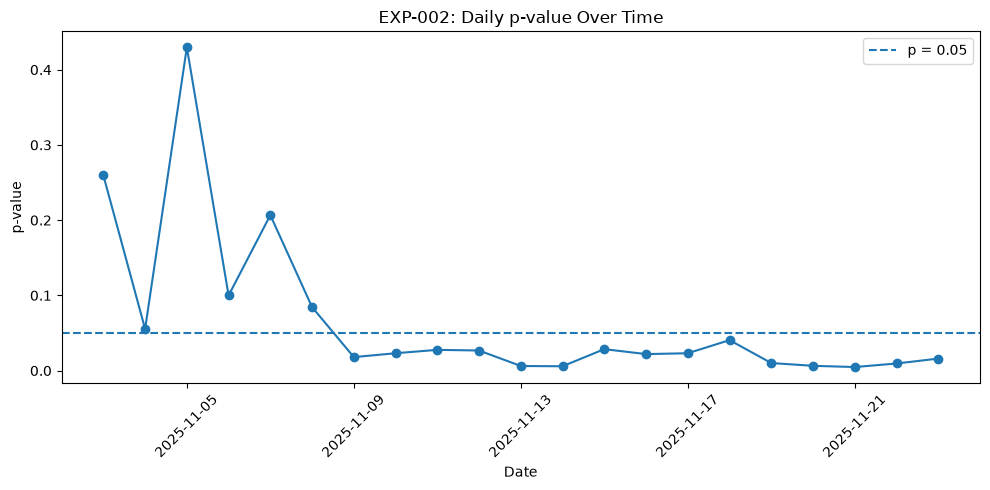

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    daily_results["date"],
    daily_results["p_value"],
    marker="o"
)

plt.axhline(
    0.05,
    linestyle="--",
    label="p = 0.05"
)

plt.xlabel("Date")
plt.ylabel("p-value")
plt.title("EXP-002: Daily p-value Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Sequential Testing Interpretation

EXP-002 first crossed the 0.05 significance threshold on **9 November**, with p = **0.01797**, and remained below 0.05 for the rest of the observation period.
If the team had stopped the experiment as soon as the result first became significant, they could have made a decision based on an early statistical signal.
This demonstrates why repeated daily checking can increase the risk of a false-positive decision and why the stopping rule should be defined before analysing the results.
